<a href="https://colab.research.google.com/github/eliasakalu/ICogLabs_AI_Projects/blob/main/Word_2_Vector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word2Vec from Scratch (Skip-gram) AG News Dataset

**Goal:** Train word embeddings using Skip-gram on a small sample of AG News,
then explore what the model learned using cosine similarity and t-SNE.

**Steps:**
1. Load raw text (AG News)
2. Clean and tokenize manually
3. Build a vocabulary
4. Generate (center, context) training pairs
5. Build and train a Skip-gram model
6. Extract the learned embedding matrix
7. Analyze with cosine similarity
8. Visualize with t-SNE


## 1. Load Untokenized Dataset

We load AG News and keep only the raw text — nothing cleaned or tokenized yet.
AG News has 4 categories (World, Sports, Business, Sci/Tech).
We sample 2000 articles per category = 8000 total, just enough to train fast
but still have a decent mix of topics.

In [60]:
# !pip install -U datasets huggingface_hub
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
import random, re
from collections import Counter
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news", split="train")
print(dataset[0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [61]:
# take 2000 words from each labels inside the datasets
random.seed(42)

labels = {0: [], 1: [], 2: [], 3: []}
for i, item in enumerate(dataset):
    labels[item['label']].append(i)

sample_index = []
for label in labels:
    sample_index += random.sample(labels[label], 400)

articles = [dataset[i]['text'] for i in sample_index]

print("Total articles sampled:", len(articles))
print(articles[0])

Total articles sampled: 1600
Euro rises to new record high 1.2937 dollars (AFP) AFP - The euro rose to a new record high against the dollar, climbing to 1.2937 dollars in late European trades.


## 2. Clean and Tokenize

The raw text has capital letters, punctuation, numbers, and sometimes
weird leftover characters. It must be clean by doing manually before anything else.

Why each step matters for Word2Vec:
- **Lowercase:** `"Apple"` and `"apple"` would otherwise be two separate
  vocabulary entries, splitting the training signal that should go to one word.
- **Remove punctuation/numbers:** prevents things like `"Reuters)"` or `"2024"`
  from being treated as real words.
- **Collapse whitespace:** cleans up extra gaps left after stripping characters.

In [62]:
def clean_data(text):
    text = text.lower()
    text = text.replace('\\\\', ' ')
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_articles = [clean_data(a) for a in articles]
tokenized_articles = [a.split() for a in cleaned_articles]

print(cleaned_articles[0])
print(tokenized_articles[0])

euro rises to new record high dollars afp afp the euro rose to a new record high against the dollar climbing to dollars in late european trades
['euro', 'rises', 'to', 'new', 'record', 'high', 'dollars', 'afp', 'afp', 'the', 'euro', 'rose', 'to', 'a', 'new', 'record', 'high', 'against', 'the', 'dollar', 'climbing', 'to', 'dollars', 'in', 'late', 'european', 'trades']


## 3. Build the Vocabulary

We count every word across all articles, then build:
- `vocab`: unique words
- `word2idx`: maps each word to an integer ID (needed for the embedding lookup)
- `idx2word`: reverse map, used later to decode row numbers back to words

Words that appear only once give the model almost no signal to learn from,
so we remove them — smaller vocab, better-trained embeddings for the words
that remain.

In [63]:
total_tokens = [word for article in tokenized_articles for word in article]
word_frequency = Counter(total_tokens)

MIN_COUNT = 2  # drop words seen less than 2 times — not enough to learn from
vocab = [word for word, count in word_frequency.items() if count >= MIN_COUNT]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(vocab)
print("Total tokens:", len(total_tokens))
print("Final vocab size:", vocab_size)

Total tokens: 61822
Final vocab size: 5331


## 4. Skip-gram Training Pairs

Skip-gram works by taking each word as a "center" and trying to predict
the words around it. For each center word, we look at a small window
of nearby words and create a (center, context) pair for each one.

We do this article by article so the window never crosses from the end
of one article into the start of another unrelated one.

In [64]:
WINDOW_SIZE = 2

def generate_pairs(tokenized_articles, word2idx, window_size):
    pairs = []
    for article in tokenized_articles:
        article_ids = [word2idx[w] for w in article if w in word2idx]
        for center_pos, center_id in enumerate(article_ids):
            start = max(0, center_pos - window_size)
            end = min(len(article_ids), center_pos + window_size + 1)
            for context_pos in range(start, end):
                if context_pos != center_pos:
                    pairs.append((center_id, article_ids[context_pos]))
    return pairs

training_pairs = generate_pairs(tokenized_articles, word2idx, WINDOW_SIZE)
print("Total training pairs:", len(training_pairs))

centers = np.array([p[0] for p in training_pairs])
contexts = np.array([p[1] for p in training_pairs])

Total training pairs: 219732


## 5. Build the Skip-gram Model

The model has two weight matrices:
- **W_in** (the Embedding layer): (shape vocab_size, embed_dim).<br>
  Looking up a word's row here is the same as multiplying a one-hot vector
  by the matrix — Keras just does the lookup directly, no need to build
  one-hot vectors by hand.
- **W_out** (the Dense layer): converts the embedding into a raw score
  for every word in the vocabulary.

SparseCategoricalCrossentropy(from_logits=True) handles softmax + loss
internally. After training we only keep W_in — that's the actual word
embeddings. W_out is thrown away.

In [65]:
EMBED_DIM = 300

class SkipGram(Model):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.target_embedding = layers.Embedding(vocab_size, embed_dim, name="w_in")
        self.output_dense = layers.Dense(vocab_size, name="w_out")

    def call(self, center_word_ids):
        x = self.target_embedding(center_word_ids)  #(batch, embed_dim)
        x = self.output_dense(x)                    #(batch, vocab_size)
        return x

model = SkipGram(vocab_size, EMBED_DIM)
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [66]:
history = model.fit(centers, contexts, epochs=10, batch_size=256, verbose=1)
embeddings = model.target_embedding.get_weights()[0]
print("Embedding matrix shape:", embeddings.shape)
model.summary()

Epoch 1/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 93s 106ms/step - accuracy: 0.0547 - loss: 7.1042
Epoch 2/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 142s 106ms/step - accuracy: 0.0548 - loss: 6.4131
Epoch 3/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 141s 106ms/step - accuracy: 0.0550 - loss: 6.2029
Epoch 4/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 142s 106ms/step - accuracy: 0.0546 - loss: 6.1106
Epoch 5/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 90s 105ms/step - accuracy: 0.0547 - loss: 6.0532
Epoch 6/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 146s 109ms/step - accuracy: 0.0550 - loss: 6.0076
Epoch 7/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 139s 106ms/step - accuracy: 0.0552 - loss: 5.9631
Epoch 8/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 90s 105ms/step - accuracy: 0.0549 - loss: 5.9238
Epoch 9/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 91s 106ms/step - accuracy: 0.0556 - loss: 5.8868
Epoch 10/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 141s 105ms/step - accuracy: 0.0553 - loss: 5.8569
Embedding matrix shape: (5331, 300)


Model: "skip_gram_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ w_in (Embedding)                │ (None, 300)            │     1,599,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ w_out (Dense)                   │ (None, 5331)           │     1,604,631 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,611,795 (36.67 MB)

 Trainable params: 3,203,931 (12.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,407,864 (24.44 MB)

## 7. Cosine Similarity Analysis

Cosine similarity measures how close two word vectors are by looking at
the angle between them — not their length.

Formula: **dot(A, B) / (||A|| * ||B||)**

- Close to **1** → very similar
- Close to **0** → unrelated
- Close to **-1** → opposite

In [72]:
def cosine_similarity(vector, vector2):
    return np.dot(vector, vector2) / (np.linalg.norm(vector) * np.linalg.norm(vector2))

def most_similar(word, embeddings, word2idx, idx2word, top_n=5):
    if word not in word2idx:
        print(f"'{word}' not in vocabulary")
        return []
    word_vec = embeddings[word2idx[word]]
    similarities = []
    for other_word, idx in word2idx.items():
        if other_word == word:
            continue
        sim = cosine_similarity(word_vec, embeddings[idx])
        similarities.append((other_word, sim))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

candidates = ['stock', 'market', 'team', 'game', 'president', 'government',
              'computer', 'company', 'win', 'season']
for w in candidates:
    print(w, 'IN VOCAB' if w in word2idx else 'missing')

stock IN VOCAB
market IN VOCAB
team IN VOCAB
game IN VOCAB
president IN VOCAB
government IN VOCAB
computer IN VOCAB
company IN VOCAB
win IN VOCAB
season IN VOCAB


In [73]:
for test_word in ['stock', 'team', 'president', 'computer']:
    print(f"\nMost similar to '{test_word}':")
    if test_word in word2idx:
        for w, score in most_similar(test_word, embeddings, word2idx, idx2word):
            print(f"  {w}: {score:.3f}")
    else:
        print("  (not in vocab — try another word from the list above)")


Most similar to 'stock':
  securities: 0.377
  holes: 0.364
  share: 0.357
  nikkei: 0.350
  indicators: 0.347

Most similar to 'team':
  football: 0.294
  summer: 0.283
  drivers: 0.282
  returning: 0.278
  berth: 0.272

Most similar to 'president':
  george: 0.415
  elect: 0.366
  thabo: 0.355
  putin: 0.345
  pervez: 0.326

Most similar to 'computer':
  ibook: 0.451
  associates: 0.347
  mcafee: 0.309
  color: 0.303
  adds: 0.300


In [74]:
def word_pair_similarity(word_a, word_b, embeddings, word2idx):
    if word_a not in word2idx or word_b not in word2idx:
        print(f"One of '{word_a}', '{word_b}' not in vocabulary")
        return None
    vec_a = embeddings[word2idx[word_a]]
    vec_b = embeddings[word2idx[word_b]]
    return cosine_similarity(vec_a, vec_b)

pairs_to_test = [
    ('stock', 'market'),
    ('team', 'game'),
    ('president', 'government'),
    ('stock', 'team')
]

for w1, w2 in pairs_to_test:
    sim = word_pair_similarity(w1, w2, embeddings, word2idx)
    if sim is not None:
        print(f"similarity('{w1}', '{w2}') = {sim:.3f}")

similarity('stock', 'market') = 0.332
similarity('team', 'game') = 0.152
similarity('president', 'government') = 0.089
similarity('stock', 'team') = 0.119


## 8. t-SNE Visualization

since the embeddings are 300-dimensional — we can't plot that directly.
t-SNE shrinks them to 2D while keeping nearby words still near each other
(roughly).


In [75]:
from sklearn.manifold import TSNE

N_WORDS = 150

top_words = [word for word, count in word_frequency.most_common(N_WORDS) if word in word2idx]
top_word_ids = [word2idx[w] for w in top_words]
top_word_vectors = embeddings[top_word_ids]

print("Vectors selected for t-SNE:", top_word_vectors.shape)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embeddings_2d = tsne.fit_transform(top_word_vectors)

print("Reduced shape:", embeddings_2d.shape)

Vectors selected for t-SNE: (150, 300)
Reduced shape: (150, 2)


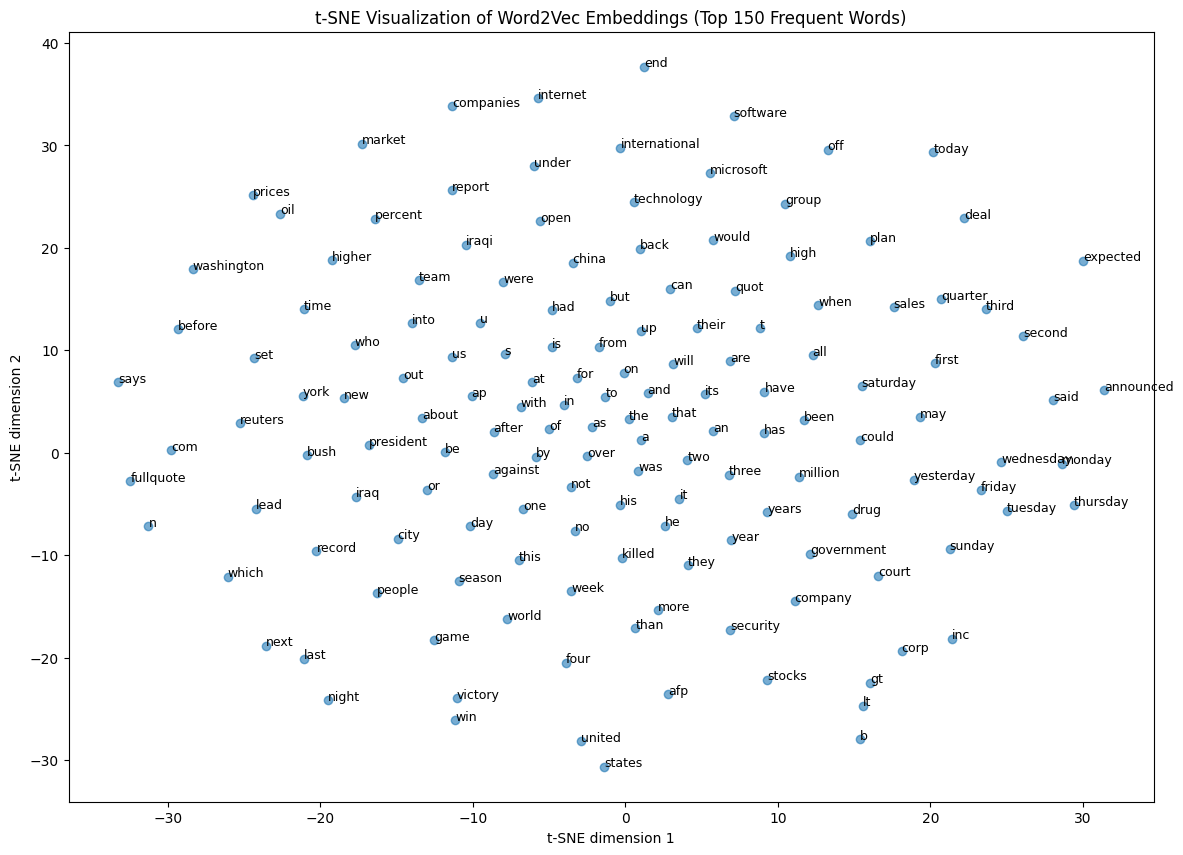

In [76]:
plt.figure(figsize=(14, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)

for i, word in enumerate(top_words):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=9)

plt.title("t-SNE Visualization of Word2Vec Embeddings (Top 150 Frequent Words)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.show()